Step 1: Explore and prepare data!

In [1]:
import pandas as pd

df = pd.read_csv("ML_dataset.csv")
to_drop = ['id','title','best_picture_nom','nominated'] #consider dropping revenue 
df = df.drop(columns=to_drop)

#turn "won" results into binary classification (0 if no wins, 1 if at least one win)
df.loc[df["won"] > 1, "won"] = 1

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45369 entries, 0 to 45368
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                45369 non-null  int64  
 1   budget              45369 non-null  float64
 2   revenue             45369 non-null  float64
 3   runtime             45369 non-null  float64
 4   genres              45369 non-null  str    
 5   director            45369 non-null  str    
 6   cast                45369 non-null  str    
 7   tomatometer_rating  45369 non-null  float64
 8   audience_rating     45369 non-null  float64
 9   won                 45369 non-null  int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 3.5 MB


In [3]:
df["won"].value_counts()


won
0    45079
1      290
Name: count, dtype: int64

In [4]:
from sklearn.model_selection import train_test_split
X = df.drop(columns='won')
y = df['won']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, stratify=y, random_state=12)

Step 2: Build a pipeline of training


In [5]:
from sklearn.pipeline import Pipeline 
from category_encoders.target_encoder import TargetEncoder
from xgboost import XGBClassifier 

estimators = [
    ('encoder', TargetEncoder()), #turns categorical data into numerical data
    ('clf', XGBClassifier(random_state=12))
]

pipe = Pipeline(steps=estimators)
pipe 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,None
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


Step 3: Set up hyperparameter tuning (to be fixed...maybe...)


In [ ]:
from skopt import BayesSearchCV 
from skopt.space import Real,Integer 

#Start by tuning learning rate, maximum tree depth, and number of estimators 
search_space = {
    'encoder__smoothing':Real(1,100, prior='uniform'),
    'clf__max_depth': Integer(2,10),
    'clf__n_estimators': Integer(100,1000),
    'clf__learning_rate': Real(0.001,1.00,prior='log-uniform')
}

opt = BayesSearchCV(pipe,search_space,cv=5,n_iter=50,scoring='roc_auc',random_state=12,n_jobs=-1)
opt.fit(X_train,y_train)


,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'clf__learning_rate': Real(low=0.00...m='normalize'), 'clf__max_depth': Integer(low=2...m='normalize'), 'clf__n_estimators': Integer(low=1...m='normalize'), 'encoder__smoothing': Real(low=1, h...m='normalize')}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'roc_auc'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


Step 5: Evaulate the model and make predictions

In [7]:
opt.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['genres', 'director', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


In [8]:
opt.best_score_

np.float64(0.8388644669176866)

In [9]:
opt.best_params_

OrderedDict([('clf__learning_rate', 0.08401856883274732),
             ('clf__max_depth', 2),
             ('clf__n_estimators', 958),
             ('encoder__smoothing', 1.0)])

In [10]:
opt.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(9074,))

In [11]:
opt.predict_proba(X_test)

array([[9.99989808e-01, 1.01715095e-05],
       [9.99927819e-01, 7.22070909e-05],
       [9.99982417e-01, 1.76012145e-05],
       ...,
       [9.99972105e-01, 2.79205851e-05],
       [9.99974191e-01, 2.58061282e-05],
       [9.99993205e-01, 6.81531310e-06]], shape=(9074, 2), dtype=float32)

In [12]:
opt.score(X_test,y_test)

0.8358722424502034

Step 6: Measure feature importance

In [13]:
opt.best_estimator_.steps

[('encoder',
  TargetEncoder(cols=['genres', 'director', 'cast'], smoothing=1.0)),
 ('clf',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=0.08401856883274732, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=2, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=958, n_jobs=None,
                num_parallel_tree=None, ...))]

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

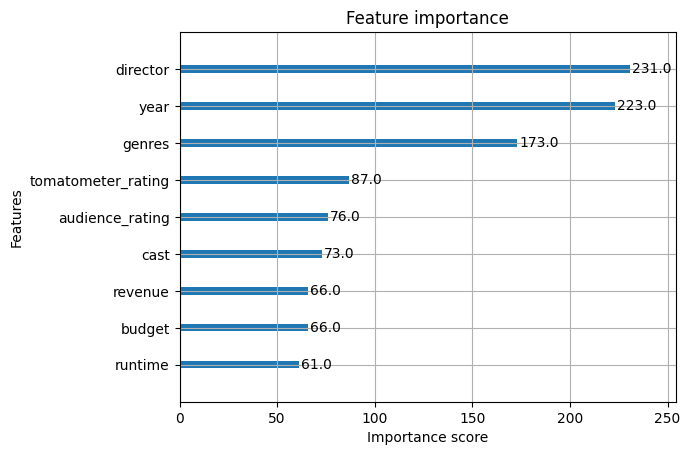

In [14]:
from xgboost import plot_importance

xgboost_step = opt.best_estimator_.steps[1]
xgboost_model = xgboost_step[1]
plot_importance(xgboost_model)